In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections.abc import Iterable

In [2]:
import pandas as pd

# Leggi tutto come stringa (per ora)
with open("relaxedMutex_runs50_nel128000_thread12345678.txt", "r") as f:
    lines = f.readlines()

# Processa ogni riga
data = []
for line in lines:
    parts = line.split()            # dividi per spazi
    tipo_coda, metodo, thread = parts[:3]   # prime 3 colonne
    valori = list(map(int, parts[3:]))      # tutti i restanti valori in lista
    data.append([tipo_coda, metodo, thread, valori])

# Crea DataFrame
df = pd.DataFrame(data, columns=["tipo_coda", "metodo", "thread", "valori"])

# Visualizza
print(df.head())

  tipo_coda      metodo   thread  \
0     deque  Push_Front  multi_1   
1     deque   Push_Back  multi_1   
2     deque   Pop_Front  multi_1   
3     deque    Pop_Back  multi_1   
4   relaxed  Push_Front  multi_1   

                                              valori  
0  [72906, 69163, 68189, 71062, 69518, 68895, 687...  
1  [62167, 70258, 63554, 61079, 68939, 64225, 606...  
2  [60993, 48802, 61899, 62133, 60790, 61383, 578...  
3  [55780, 61030, 59528, 59880, 57689, 64010, 637...  
4  [44880, 46247, 45051, 47058, 44561, 42622, 446...  


## sigle thread

In [3]:
def plot(data_list, title, labels):

    fig, ax = plt.subplots(figsize=[8, 8])

    boxes = []
    ticks = []

    for i in range(0,len(data_list)):
        boxes.append(data_list[i])
        ticks.append(labels[i])

    bplot = ax.boxplot(boxes, showfliers=False)
    # Etichette per gli assi
    ax.set_xticks(range(1,len(labels)+1),ticks)
    ax.set(ylabel = 'Microseconds')
    ax.set(title = title)
    ax.set_yscale('log')

    for median in bplot['medians']:
        median.set_color('red')
    plt.figtext(0.78, 0.9, f"runs: {len(data_list[0])}\nn_elem: {n_elem}", fontsize=9, 
            bbox=dict(facecolor='white', edgecolor='black'))
    plt.show()

In [4]:
code = ["deque","relaxed","deferred","blocking"]
metodi = ["Push_Front","Push_Back","Pop_Front","Pop_Back","random"]
thread = ["single", "multi_1", "multi_2","multi_3", "multi_4","multi_5", "multi_6","multi_7","multi_8"]

for c in code:
    for m in metodi:
        for t in thread:
            subset = df[(df["tipo_coda"]==c) & (df["metodo"]==m) & (df["thread"]==t)]
            if not subset.empty:
                valori = subset.iloc[0]["valori"]
                # Crea variabile dinamica
                nome_var = f"{c}_{m}_{t}"
                globals()[nome_var] = valori


pop back

=== Pop_Back Single Thread ===
deque: 47412.5
blocking: 52513.0
deferred: 52191.5
relaxed: 52334.0


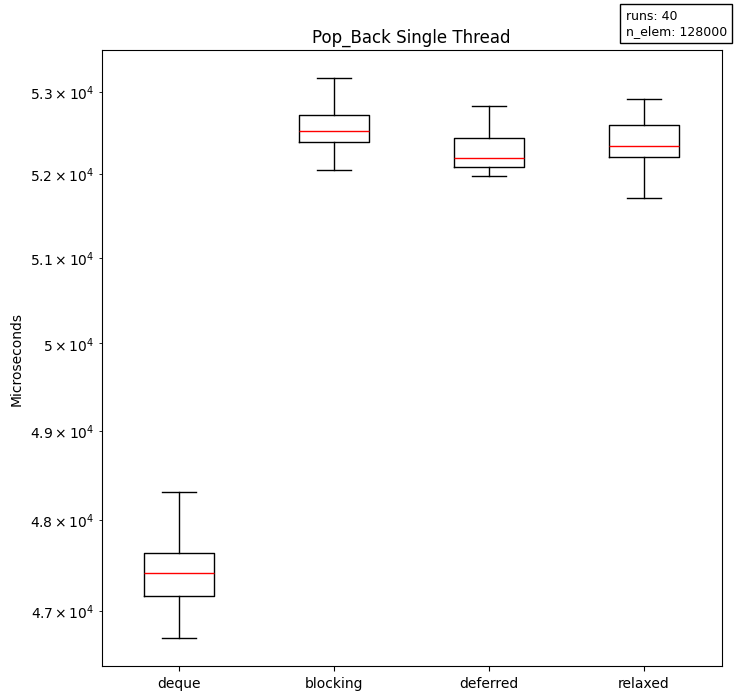


=== Pop_Front Single Thread ===
deque: 48663.5
blocking: 52326.5
deferred: 52021.5
relaxed: 52224.5


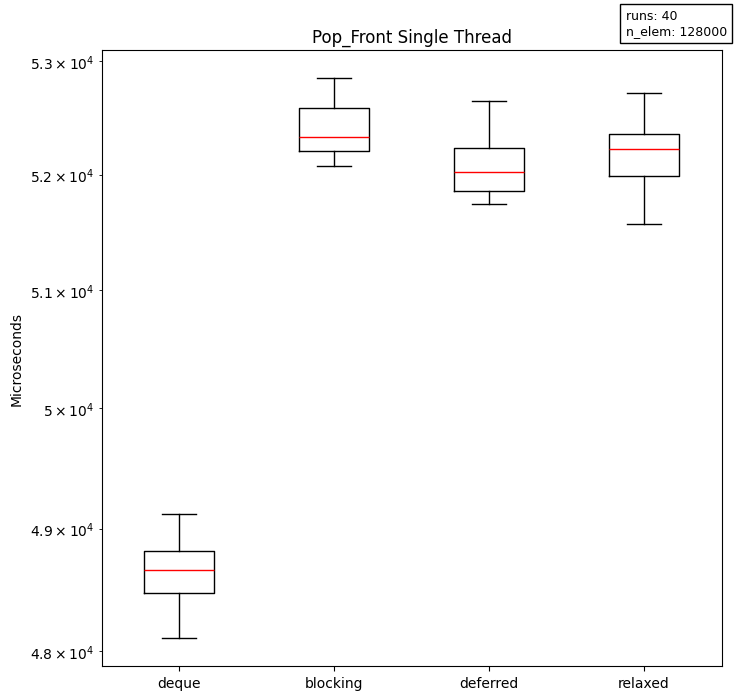


=== Push_Back Single Thread ===
deque: 55943.5
blocking: 39359.5
deferred: 38863.0
relaxed: 37914.0


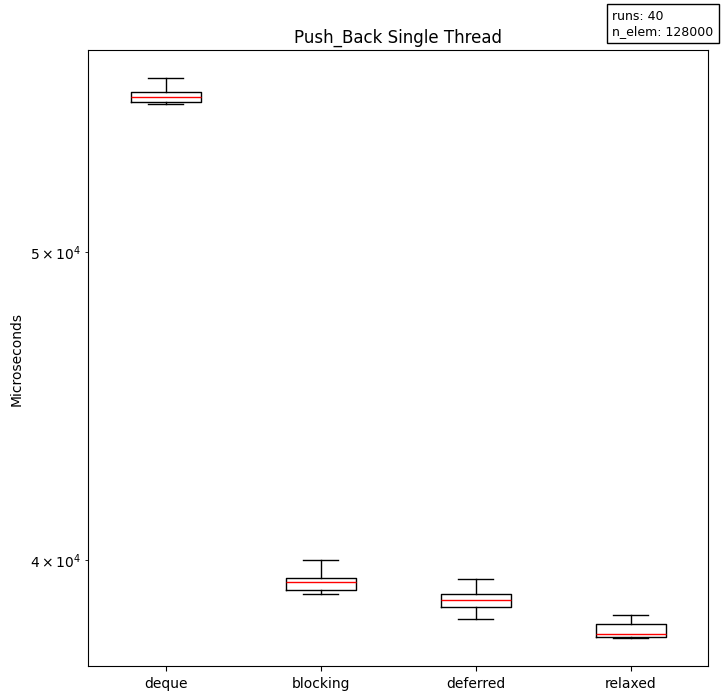


=== Push_Front Single Thread ===
deque: 56779.5
blocking: 38862.5
deferred: 38292.5
relaxed: 38695.0


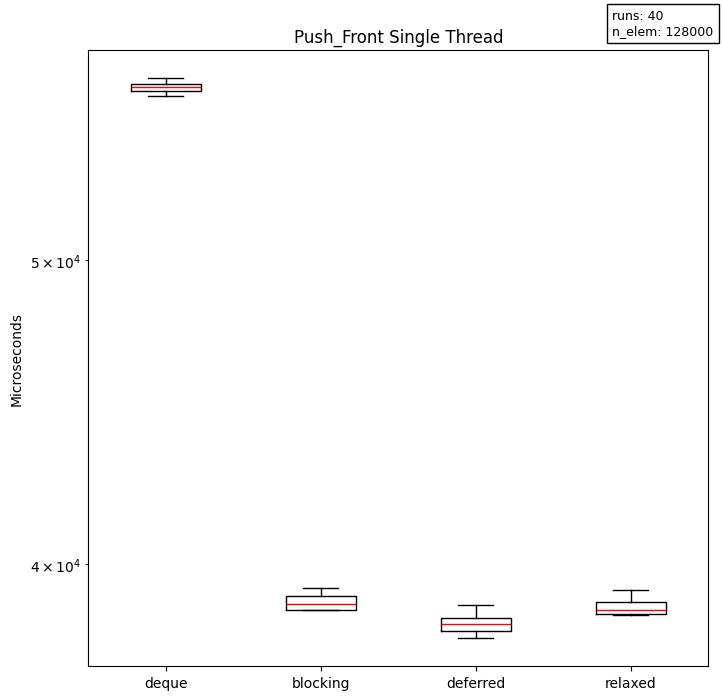

In [6]:
# dati test
nomi = ["deque", "blocking", "deferred", "relaxed"]

# ===================== DATI SINGLE THREAD =====================
# POP_BACK per thread single
dati_pop_back_single = [
    deque_Pop_Back_single,
    blocking_Pop_Back_single,
    deferred_Pop_Back_single,
    relaxed_Pop_Back_single
]

# POP_FRONT per thread single
dati_pop_front_single = [
    deque_Pop_Front_single,
    blocking_Pop_Front_single,
    deferred_Pop_Front_single,
    relaxed_Pop_Front_single
]

# PUSH_BACK per thread single
dati_push_back_single = [
    deque_Push_Back_single,
    blocking_Push_Back_single,
    deferred_Push_Back_single,
    relaxed_Push_Back_single
]

# PUSH_FRONT per thread single
dati_push_front_single = [
    deque_Push_Front_single,
    blocking_Push_Front_single,
    deferred_Push_Front_single,
    relaxed_Push_Front_single
]

n_elem = 128000

# ===================== Calcola e stampa le mediane =====================
print("=== Pop_Back Single Thread ===")
for nome, dati in zip(nomi, dati_pop_back_single):
    mediana = np.median(dati)
    print(f"{nome}: {mediana}")
plot(dati_pop_back_single, "Pop_Back Single Thread", nomi)

print("\n=== Pop_Front Single Thread ===")
for nome, dati in zip(nomi, dati_pop_front_single):
    mediana = np.median(dati)
    print(f"{nome}: {mediana}")
plot(dati_pop_front_single, "Pop_Front Single Thread", nomi)

print("\n=== Push_Back Single Thread ===")
for nome, dati in zip(nomi, dati_push_back_single):
    mediana = np.median(dati)
    print(f"{nome}: {mediana}")
plot(dati_push_back_single, "Push_Back Single Thread", nomi)

print("\n=== Push_Front Single Thread ===")
for nome, dati in zip(nomi, dati_push_front_single):
    mediana = np.median(dati)
    print(f"{nome}: {mediana}")
plot(dati_push_front_single, "Push_Front Single Thread", nomi)


## multithread

In [8]:
n_thread = [1,2,3,4,5,6,7,8] #,4,8,12,16] #,12,16] #hard code in .sh copialo da li
n_elem = 128000 ##hard code quando fai run di fie.sh

In [9]:
def multi_plot(data1, data2, data3, data4, title, labels, n_threads):
    fig, ax = plt.subplots(figsize=[10, 10])

    boxes = []
    colors = []
    group_positions = []  # Per le etichette centrate

    color_map = ["peachpuff", "orange", "yellow", "blue"]

    for i in range(len(n_threads)):
        boxes.extend([data1[i], data2[i], data3[i], data4[i]])
        colors.extend(color_map)
        # Ogni gruppo di 4 box parte alla posizione 4*i+1 → il centro è +1.5
        group_center = 4 * i + 2.5
        group_positions.append(group_center)

    # Crea boxplot
    bplot = ax.boxplot(boxes, showfliers=False, patch_artist=True)

    # Colori per ogni box
    for patch, color in zip(bplot['boxes'], colors):
        patch.set_facecolor(color)

    # Etichette centrate per ogni gruppo
    ax.set_xticks(group_positions)
    ax.set_xticklabels([str(n) for n in n_threads])

    # Etichette e titolo
    ax.set_ylabel('Microseconds')
    ax.set_xlabel('n_threads')
    ax.set_title(title, loc='left')
    ax.set_yscale('log')
    
    # Legenda (usiamo solo il primo gruppo per i colori)
    legend_handles = [bplot["boxes"][i] for i in range(4)]
    ax.legend(legend_handles, labels, loc='upper right')

    # Mediane in rosso
    for median in bplot['medians']:
        median.set_color('red')

    plt.figtext(0.78, 0.98, f"runs: {len(data1[0])}\nn_elem: {n_elem}", fontsize=9, 
            bbox=dict(facecolor='white', edgecolor='black'))

    plt.tight_layout()
    plt.show()

    # ======= Calcolo e stampa delle mediane numeriche =======
    print(f"\n=== Median values for {title} ===")
    medians = [np.median(b) for b in boxes]
    
    for i, n in enumerate(n_threads):
        print(f"\nThreads = {n}")
        for j, label in enumerate(labels):
            idx = i * 4 + j
            print(f"  {label:>12}: {medians[idx]:.2f}")


In [10]:
# ===================== DEQUE =====================
dati_deque_Push_Front_multi = [
    deque_Push_Front_multi_1,
    deque_Push_Front_multi_2,
    deque_Push_Front_multi_3,
    deque_Push_Front_multi_4,
    deque_Push_Front_multi_5,
    deque_Push_Front_multi_6,
    deque_Push_Front_multi_7,
    deque_Push_Front_multi_8
]

dati_deque_Push_Back_multi = [
    deque_Push_Back_multi_1,
    deque_Push_Back_multi_2,
    deque_Push_Back_multi_3,
    deque_Push_Back_multi_4,
    deque_Push_Back_multi_5,
    deque_Push_Back_multi_6,
    deque_Push_Back_multi_7,
    deque_Push_Back_multi_8
]

dati_deque_Pop_Front_multi = [
    deque_Pop_Front_multi_1,
    deque_Pop_Front_multi_2,
    deque_Pop_Front_multi_3,
    deque_Pop_Front_multi_4,
    deque_Pop_Front_multi_5,
    deque_Pop_Front_multi_6,
    deque_Pop_Front_multi_7,
    deque_Pop_Front_multi_8
]

dati_deque_Pop_Back_multi = [
    deque_Pop_Back_multi_1,
    deque_Pop_Back_multi_2,
    deque_Pop_Back_multi_3,
    deque_Pop_Back_multi_4,
    deque_Pop_Back_multi_5,
    deque_Pop_Back_multi_6,
    deque_Pop_Back_multi_7,
    deque_Pop_Back_multi_8
]

# ===================== RELAXED =====================
dati_relaxed_Push_Front_multi = [
    relaxed_Push_Front_multi_1,
    relaxed_Push_Front_multi_2,
    relaxed_Push_Front_multi_3,
    relaxed_Push_Front_multi_4,
    relaxed_Push_Front_multi_5,
    relaxed_Push_Front_multi_6,
    relaxed_Push_Front_multi_7,
    relaxed_Push_Front_multi_8
]

dati_relaxed_Push_Back_multi = [
    relaxed_Push_Back_multi_1,
    relaxed_Push_Back_multi_2,
    relaxed_Push_Back_multi_3,
    relaxed_Push_Back_multi_4,
    relaxed_Push_Back_multi_5,
    relaxed_Push_Back_multi_6,
    relaxed_Push_Back_multi_7,
    relaxed_Push_Back_multi_8
]

dati_relaxed_Pop_Front_multi = [
    relaxed_Pop_Front_multi_1,
    relaxed_Pop_Front_multi_2,
    relaxed_Pop_Front_multi_3,
    relaxed_Pop_Front_multi_4,
    relaxed_Pop_Front_multi_5,
    relaxed_Pop_Front_multi_6,
    relaxed_Pop_Front_multi_7,
    relaxed_Pop_Front_multi_8
]

dati_relaxed_Pop_Back_multi = [
    relaxed_Pop_Back_multi_1,
    relaxed_Pop_Back_multi_2,
    relaxed_Pop_Back_multi_3,
    relaxed_Pop_Back_multi_4,
    relaxed_Pop_Back_multi_5,
    relaxed_Pop_Back_multi_6,
    relaxed_Pop_Back_multi_7,
    relaxed_Pop_Back_multi_8
]

# ===================== DEFERRED =====================
dati_deferred_Push_Front_multi = [
    deferred_Push_Front_multi_1,
    deferred_Push_Front_multi_2,
    deferred_Push_Front_multi_3,
    deferred_Push_Front_multi_4,
    deferred_Push_Front_multi_5,
    deferred_Push_Front_multi_6,
    deferred_Push_Front_multi_7,
    deferred_Push_Front_multi_8
]

dati_deferred_Push_Back_multi = [
    deferred_Push_Back_multi_1,
    deferred_Push_Back_multi_2,
    deferred_Push_Back_multi_3,
    deferred_Push_Back_multi_4,
    deferred_Push_Back_multi_5,
    deferred_Push_Back_multi_6,
    deferred_Push_Back_multi_7,
    deferred_Push_Back_multi_8
]

dati_deferred_Pop_Front_multi = [
    deferred_Pop_Front_multi_1,
    deferred_Pop_Front_multi_2,
    deferred_Pop_Front_multi_3,
    deferred_Pop_Front_multi_4,
    deferred_Pop_Front_multi_5,
    deferred_Pop_Front_multi_6,
    deferred_Pop_Front_multi_7,
    deferred_Pop_Front_multi_8
]

dati_deferred_Pop_Back_multi = [
    deferred_Pop_Back_multi_1,
    deferred_Pop_Back_multi_2,
    deferred_Pop_Back_multi_3,
    deferred_Pop_Back_multi_4,
    deferred_Pop_Back_multi_5,
    deferred_Pop_Back_multi_6,
    deferred_Pop_Back_multi_7,
    deferred_Pop_Back_multi_8
]

# ===================== BLOCKING =====================
dati_blocking_Push_Front_multi = [
    blocking_Push_Front_multi_1,
    blocking_Push_Front_multi_2,
    blocking_Push_Front_multi_3,
    blocking_Push_Front_multi_4,
    blocking_Push_Front_multi_5,
    blocking_Push_Front_multi_6,
    blocking_Push_Front_multi_7,
    blocking_Push_Front_multi_8
]

dati_blocking_Push_Back_multi = [
    blocking_Push_Back_multi_1,
    blocking_Push_Back_multi_2,
    blocking_Push_Back_multi_3,
    blocking_Push_Back_multi_4,
    blocking_Push_Back_multi_5,
    blocking_Push_Back_multi_6,
    blocking_Push_Back_multi_7,
    blocking_Push_Back_multi_8
]

dati_blocking_Pop_Front_multi = [
    blocking_Pop_Front_multi_1,
    blocking_Pop_Front_multi_2,
    blocking_Pop_Front_multi_3,
    blocking_Pop_Front_multi_4,
    blocking_Pop_Front_multi_5,
    blocking_Pop_Front_multi_6,
    blocking_Pop_Front_multi_7,
    blocking_Pop_Front_multi_8
]

dati_blocking_Pop_Back_multi = [
    blocking_Pop_Back_multi_1,
    blocking_Pop_Back_multi_2,
    blocking_Pop_Back_multi_3,
    blocking_Pop_Back_multi_4,
    blocking_Pop_Back_multi_5,
    blocking_Pop_Back_multi_6,
    blocking_Pop_Back_multi_7,
    blocking_Pop_Back_multi_8
]


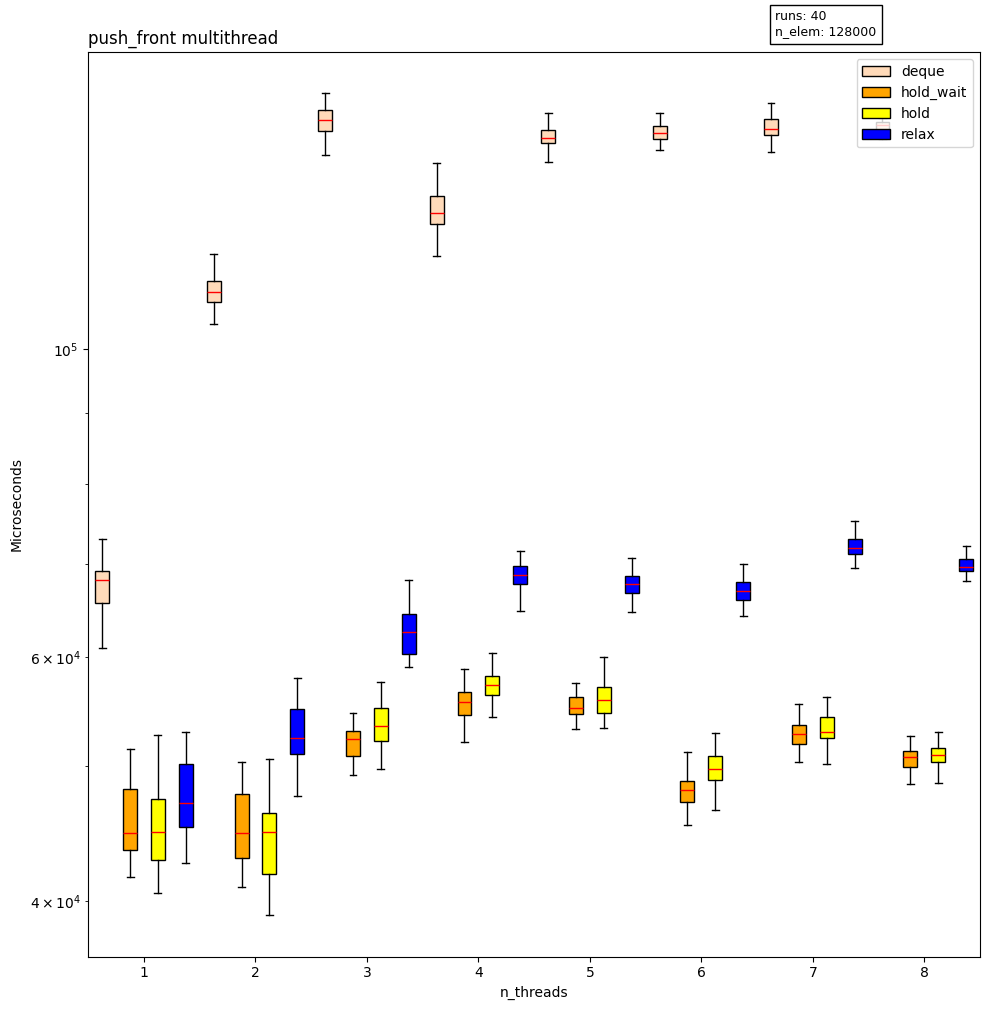


=== Median values for push_front multithread ===

Threads = 1
         deque: 68208.50
     hold_wait: 44731.00
          hold: 44803.50
         relax: 47031.50

Threads = 2
         deque: 109972.00
     hold_wait: 44737.50
          hold: 44809.00
         relax: 52398.50

Threads = 3
         deque: 146450.50
     hold_wait: 52358.50
          hold: 53515.50
         relax: 62500.00

Threads = 4
         deque: 125387.00
     hold_wait: 55609.50
          hold: 57276.50
         relax: 68674.00

Threads = 5
         deque: 142168.50
     hold_wait: 55142.00
          hold: 55802.00
         relax: 67688.50

Threads = 6
         deque: 143284.00
     hold_wait: 48097.50
          hold: 49747.50
         relax: 66951.00

Threads = 7
         deque: 144138.50
     hold_wait: 52726.50
          hold: 52962.50
         relax: 71829.50

Threads = 8
         deque: 145067.50
     hold_wait: 50771.00
          hold: 50954.00
         relax: 69706.50


In [11]:
multi_plot(dati_deque_Push_Front_multi, dati_blocking_Push_Front_multi, dati_deferred_Push_Front_multi,dati_relaxed_Push_Front_multi , "push_front multithread", ["deque","hold_wait","hold","relax"], n_thread)

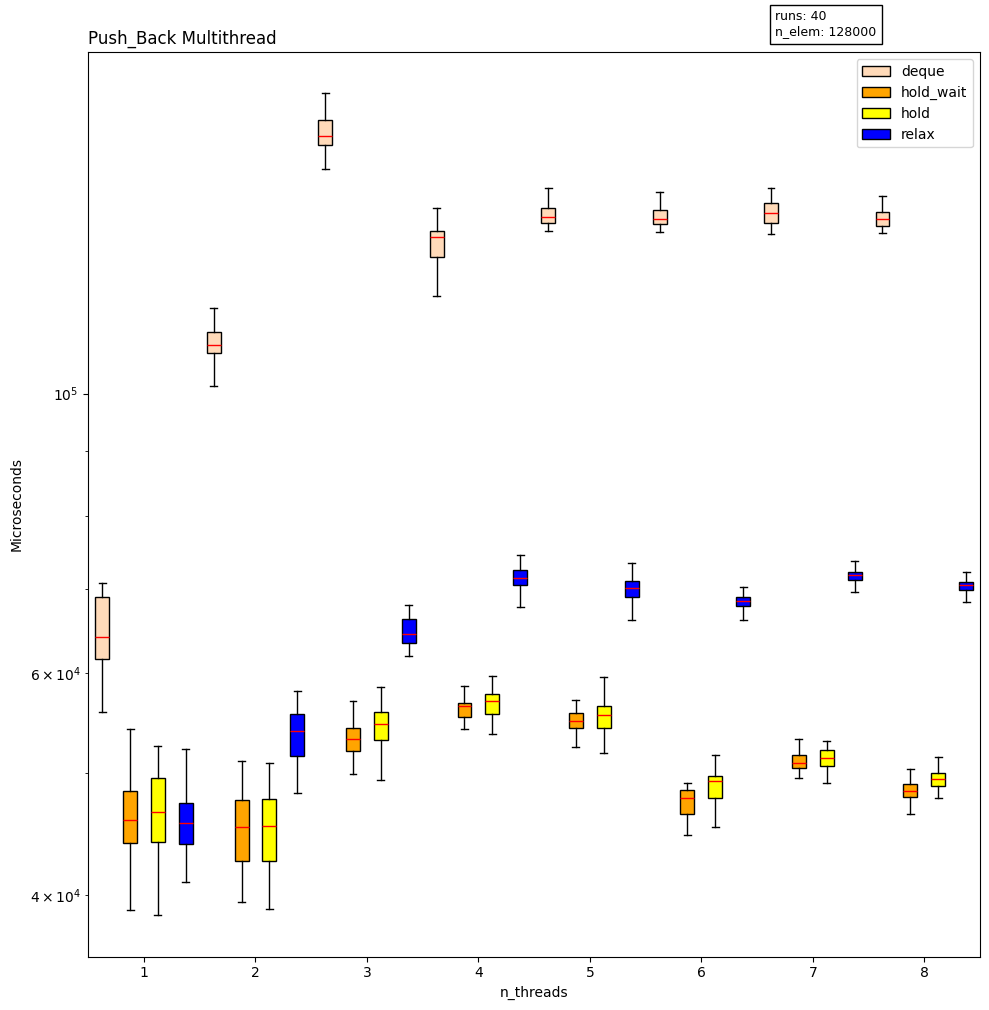


=== Median values for Push_Back Multithread ===

Threads = 1
         deque: 64061.00
     hold_wait: 45849.50
          hold: 46609.00
         relax: 45642.50

Threads = 2
         deque: 109214.00
     hold_wait: 45348.00
          hold: 45371.50
         relax: 54040.00

Threads = 3
         deque: 159985.50
     hold_wait: 53191.50
          hold: 54688.50
         relax: 64468.00

Threads = 4
         deque: 133200.00
     hold_wait: 56508.00
          hold: 57058.00
         relax: 71401.50

Threads = 5
         deque: 138075.50
     hold_wait: 55028.00
          hold: 55594.50
         relax: 70129.50

Threads = 6
         deque: 137620.00
     hold_wait: 47768.00
          hold: 49235.50
         relax: 68509.50

Threads = 7
         deque: 139134.50
     hold_wait: 50947.50
          hold: 51364.00
         relax: 71748.50

Threads = 8
         deque: 137631.00
     hold_wait: 48430.50
          hold: 49436.50
         relax: 70450.00


In [12]:
multi_plot(
    dati_deque_Push_Back_multi,
    dati_blocking_Push_Back_multi,
    dati_deferred_Push_Back_multi,
    dati_relaxed_Push_Back_multi,
    "Push_Back Multithread",
    ["deque","hold_wait","hold","relax"], n_thread
)

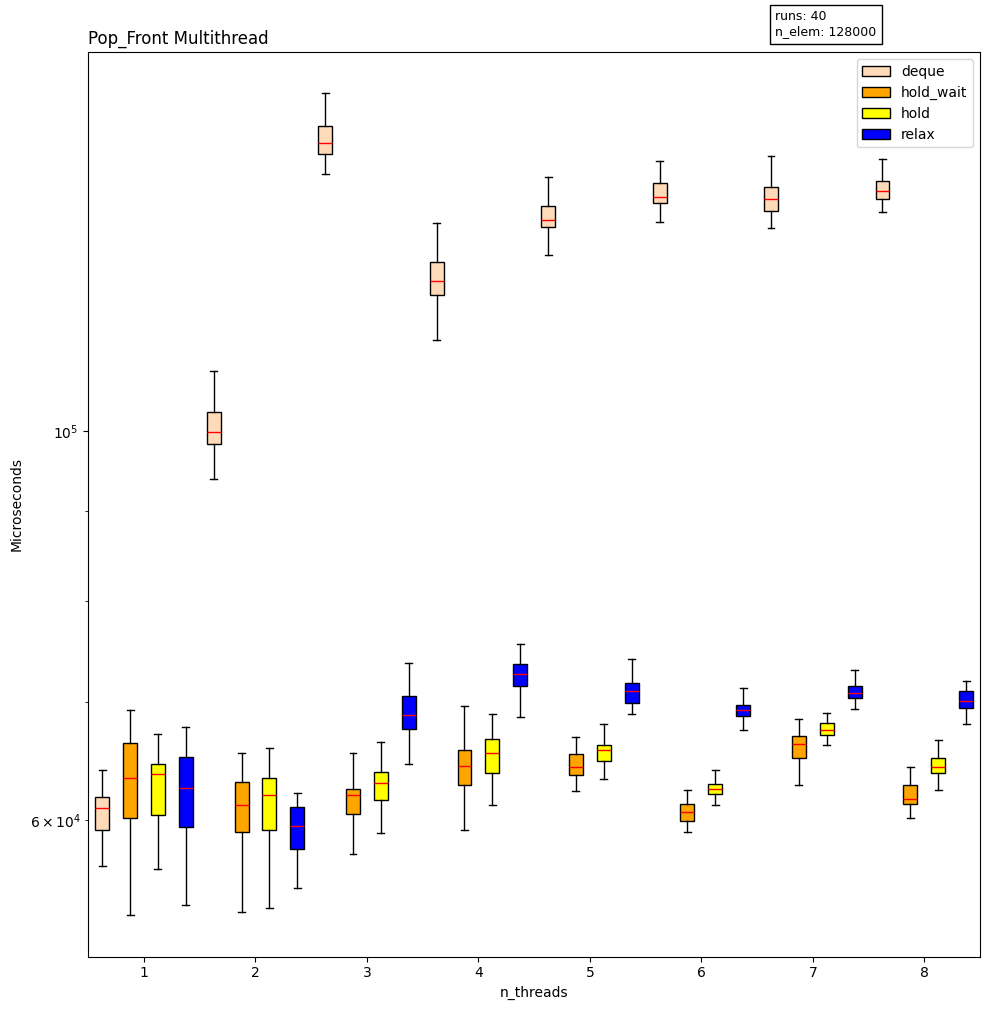


=== Median values for Pop_Front Multithread ===

Threads = 1
         deque: 60959.50
     hold_wait: 63373.00
          hold: 63736.50
         relax: 62554.00

Threads = 2
         deque: 99768.00
     hold_wait: 61171.50
          hold: 62010.50
         relax: 59521.00

Threads = 3
         deque: 145872.00
     hold_wait: 61952.00
          hold: 62940.00
         relax: 68893.50

Threads = 4
         deque: 121691.50
     hold_wait: 64390.50
          hold: 65536.50
         relax: 72683.00

Threads = 5
         deque: 131939.00
     hold_wait: 64312.50
          hold: 65783.00
         relax: 71053.00

Threads = 6
         deque: 135922.00
     hold_wait: 60610.50
          hold: 62505.50
         relax: 69321.00

Threads = 7
         deque: 135563.50
     hold_wait: 66240.50
          hold: 67541.00
         relax: 70880.00

Threads = 8
         deque: 137069.50
     hold_wait: 61643.50
          hold: 64328.00
         relax: 70121.00


In [13]:
multi_plot(
    dati_deque_Pop_Front_multi,
    dati_blocking_Pop_Front_multi,
    dati_deferred_Pop_Front_multi,
    dati_relaxed_Pop_Front_multi,
    "Pop_Front Multithread",
    ["deque","hold_wait","hold","relax"], n_thread
)

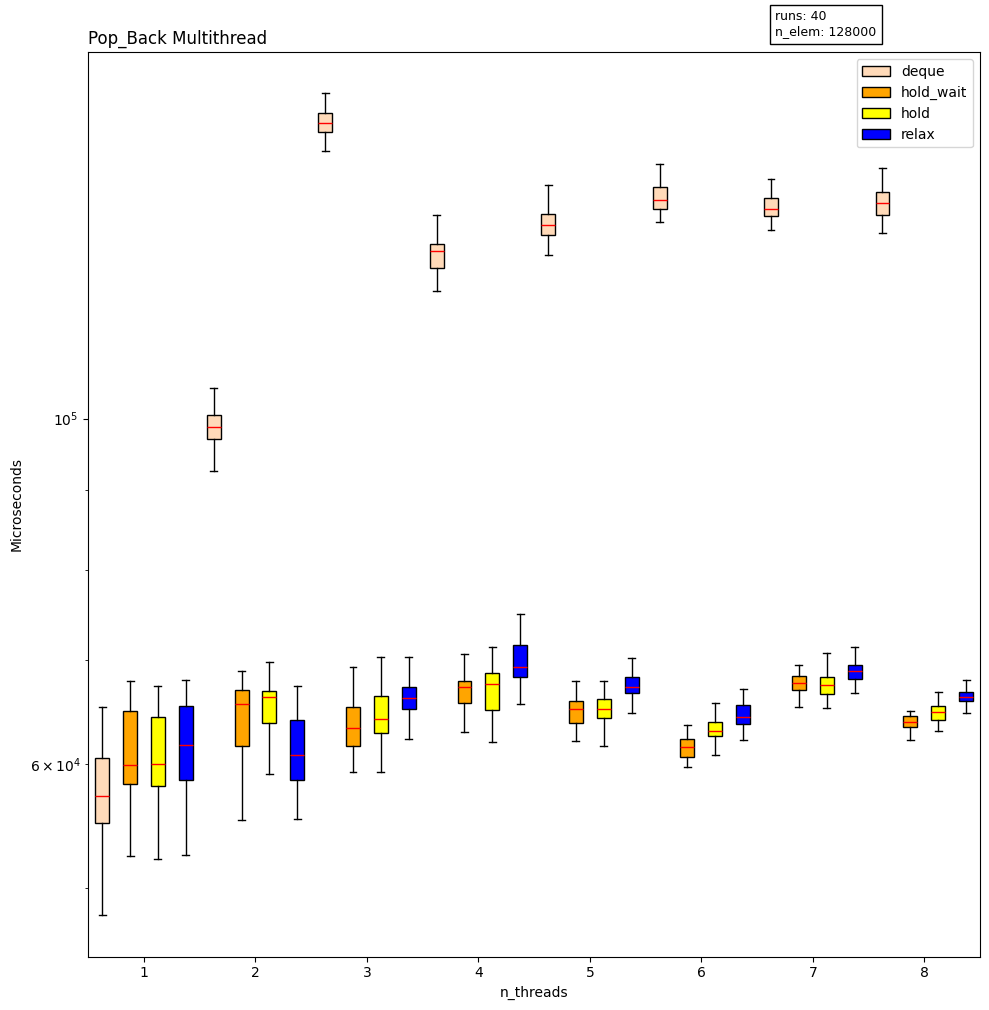


=== Median values for Pop_Back Multithread ===

Threads = 1
         deque: 57265.50
     hold_wait: 59891.00
          hold: 60052.50
         relax: 61760.00

Threads = 2
         deque: 98746.50
     hold_wait: 65562.00
          hold: 66271.50
         relax: 60784.50

Threads = 3
         deque: 154781.50
     hold_wait: 63271.50
          hold: 64107.00
         relax: 66149.50

Threads = 4
         deque: 128109.00
     hold_wait: 67213.00
          hold: 67591.00
         relax: 69243.00

Threads = 5
         deque: 133056.50
     hold_wait: 65109.50
          hold: 65113.50
         relax: 67248.50

Threads = 6
         deque: 138057.00
     hold_wait: 61589.00
          hold: 63041.50
         relax: 64357.00

Threads = 7
         deque: 136381.00
     hold_wait: 67651.00
          hold: 67484.00
         relax: 68893.00

Threads = 8
         deque: 137489.50
     hold_wait: 63895.00
          hold: 64781.00
         relax: 66226.50


In [14]:
multi_plot(
    dati_deque_Pop_Back_multi,
    dati_blocking_Pop_Back_multi,
    dati_deferred_Pop_Back_multi,
    dati_relaxed_Pop_Back_multi,
    "Pop_Back Multithread",
    ["deque","hold_wait","hold","relax"], n_thread
)

## Random

In [15]:
# ===================== DEQUE =====================
dati_deque_random_multi = [
    deque_random_multi_1,
    deque_random_multi_2,
    deque_random_multi_3,
    deque_random_multi_4,
    deque_random_multi_5,
    deque_random_multi_6,
    deque_random_multi_7,
    deque_random_multi_8
]

# ===================== RELAXED =====================
dati_relaxed_random_multi = [
    relaxed_random_multi_1,
    relaxed_random_multi_2,
    relaxed_random_multi_3,
    relaxed_random_multi_4,
    relaxed_random_multi_5,
    relaxed_random_multi_6,
    relaxed_random_multi_7,
    relaxed_random_multi_8
]

# ===================== DEFERRED =====================
dati_deferred_random_multi = [
    deferred_random_multi_1,
    deferred_random_multi_2,
    deferred_random_multi_3,
    deferred_random_multi_4,
    deferred_random_multi_5,
    deferred_random_multi_6,
    deferred_random_multi_7,
    deferred_random_multi_8
]

# ===================== BLOCKING =====================
dati_blocking_random_multi = [
    blocking_random_multi_1,
    blocking_random_multi_2,
    blocking_random_multi_3,
    blocking_random_multi_4,
    blocking_random_multi_5,
    blocking_random_multi_6,
    blocking_random_multi_7,
    blocking_random_multi_8
]


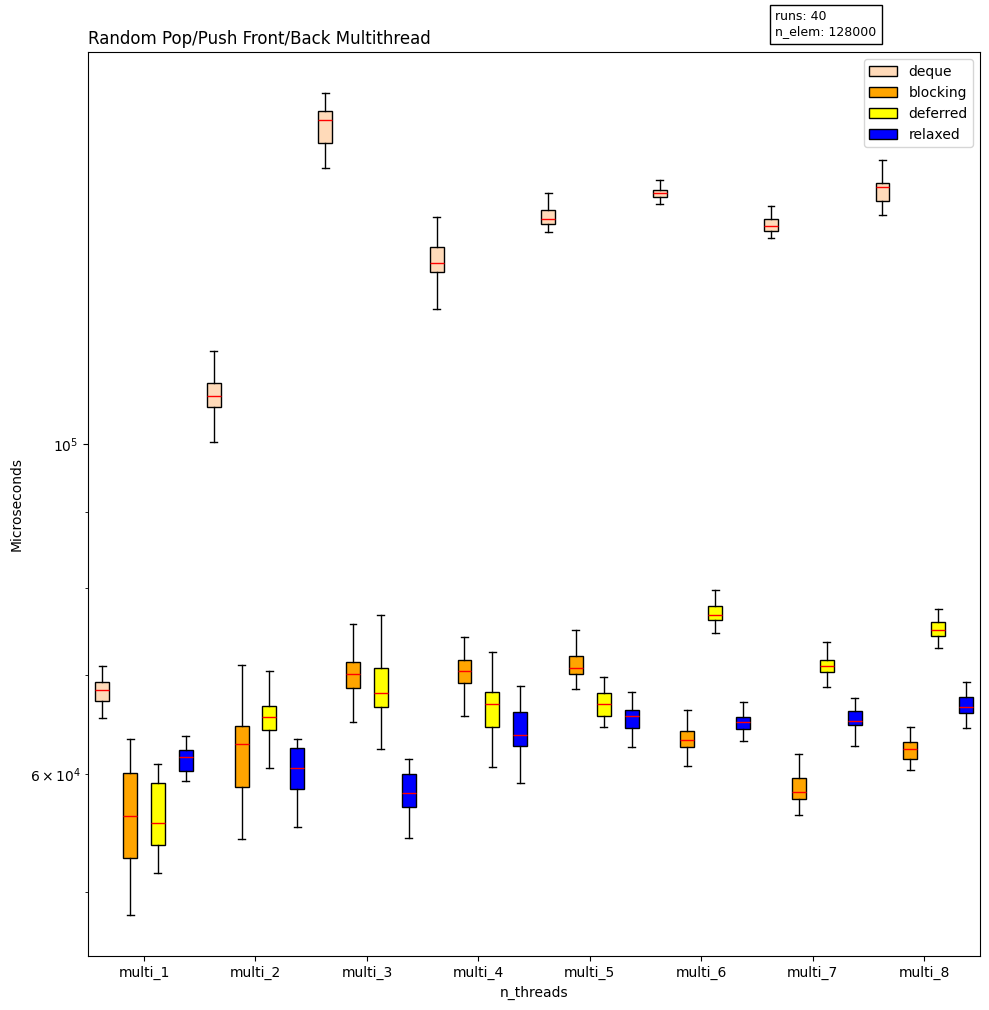


=== Median values for Random Pop/Push Front/Back Multithread ===

Threads = multi_1
         deque: 68356.50
      blocking: 56242.50
      deferred: 55626.00
       relaxed: 61664.00

Threads = multi_2
         deque: 107758.00
      blocking: 62870.00
      deferred: 65601.50
       relaxed: 60576.50

Threads = multi_3
         deque: 165134.00
      blocking: 70037.00
      deferred: 68065.50
       relaxed: 58316.50

Threads = multi_4
         deque: 132293.00
      blocking: 70442.00
      deferred: 66869.50
       relaxed: 63736.50

Threads = multi_5
         deque: 141676.00
      blocking: 70740.50
      deferred: 66915.50
       relaxed: 65705.50

Threads = multi_6
         deque: 147349.50
      blocking: 63249.50
      deferred: 76776.00
       relaxed: 65090.00

Threads = multi_7
         deque: 140044.00
      blocking: 58404.50
      deferred: 70984.00
       relaxed: 65166.50

Threads = multi_8
         deque: 148784.50
      blocking: 62403.00
      deferred: 74953.50


In [16]:
multi_plot(
    dati_deque_random_multi,
    dati_blocking_random_multi,
    dati_deferred_random_multi,
    dati_relaxed_random_multi,
    "Random Pop/Push Front/Back Multithread",
    ["deque","blocking","deferred","relaxed"],
    ["multi_1", "multi_2", "multi_3", "multi_4","multi_5", "multi_6", "multi_7", "multi_8"]
)
